# Non-Equilibrium Steady States (NESS) on 2D Periodic Lattices

## Implementazione Completa: Da Detailed Balance a NESS

Questo notebook implementa la costruzione di uno stato stazionario di non-equilibrio (NESS) su un reticolo periodico 2D.

### Convenzioni di Notazione

- $q_{ij}$ = rate di transizione da $j$ a $i$ (cioè $j \to i$)
- $J_{ij}$ = corrente stazionaria da $j$ a $i$
- $J_{ij} = q_{ij} \pi_j - q_{ji} \pi_i$
- Divergenza al nodo $i$: $d_i = \sum_j J_{ij}$ (probabilità netta entrante)

### Procedimento

1. Costruire un reticolo periodico 2D
2. Definire rate di detailed balance: $w^{\text{db}}_{ij} = A_{ij} \frac{v_i}{v_j} - \lambda \delta_{ij}$
3. Dirigere M edges (zerare alcune reverse rates)
4. Calcolare le divergenze create
5. Risolvere per le correnti compensative via incidence matrix
6. Costruire la matrice NESS finale
7. Verificare che $\pi_i = v_i^2$ rimanga stazionaria
8. Visualizzare correnti e decomposizione DB/NESS


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import networkx as nx
from scipy.linalg import eigh
import warnings
warnings.filterwarnings('ignore')

# Stile dark
plt.rcParams.update({
    'figure.facecolor': '#0a0a15',
    'axes.facecolor':   '#0a0a15',
    'axes.edgecolor':   '#3d3d5c',
    'axes.labelcolor':  '#c0c0e0',
    'xtick.color':      '#9090b0',
    'ytick.color':      '#9090b0',
    'text.color':       '#c0c0e0',
    'grid.color':       '#1a1a30',
    'grid.alpha':        0.4,
    'font.size':         10,
})

print('✓ Imports caricati')


✓ Imports caricati


## Step 1: Costruzione del Reticolo Periodico 2D (Toro)


In [ ]:
def build_torus(Lx, Ly):
    """
    Costruisce un reticolo 2D periodico (toro) di dimensione Lx × Ly.

    Returns:
        N: numero di nodi
        A: matrice di adiacenza (simmetrica)
        pos: dict {node_id: (x, y)} per plotting
        edges: lista di edges non ordinati {i,j}
        node: funzione (x,y) -> node_id
    """
    N = Lx * Ly
    A = np.zeros((N, N))
    pos = {}
    edges_set = set()

    def node(x, y):
        """Converte coordinate (x,y) in node index con periodic BC."""
        return (x % Lx) * Ly + (y % Ly)

    # Costruisci il reticolo con boundary conditions periodiche
    for x in range(Lx):
        for y in range(Ly):
            i = node(x, y)
            pos[i] = (x, y)

            # Vicino a destra (periodic in x)
            j = node(x + 1, y)
            A[i, j] = A[j, i] = 1.0
            edges_set.add((min(i,j), max(i,j)))

            # Vicino sopra (periodic in y)
            j = node(x, y + 1)
            A[i, j] = A[j, i] = 1.0
            edges_set.add((min(i,j), max(i,j)))

    edges = list(edges_set)
    return N, A, pos, edges, node


# Parametri del reticolo
Lx, Ly = 5, 5
N, A, pos, edges, node_fn = build_torus(Lx, Ly)

print(f'Reticolo: {Lx} × {Ly} (toro)')
print(f'Nodi N = {N}')
print(f'Edges  = {len(edges)}')
print(f'Cycle rank = {len(edges) - N + 1}')
print(f'A è simmetrica: {np.allclose(A, A.T)}')


Reticolo: 5 × 5 (toro)
Nodi N = 25
Edges  = 50
Cycle rank = 26
A è simmetrica: True


## Step 2: Rate di Detailed Balance

Calcoliamo:
$$w^{\text{db}}_{ij} = A_{ij} \frac{v_i}{v_j} - \lambda \delta_{ij}$$

dove $v_i$ è l'autovettore destro della matrice di adiacenza $A$ associato all'autovalore massimo $\lambda$.

Per $A$ simmetrica: $\hat{v}_i = v_i$, quindi $\pi_i = v_i^2$.


In [ ]:
def compute_db_rates(A):
    """
    Calcola le rate di detailed balance.

    Convenzione: w_db[i,j] è la rate per andare da j a i.

    Returns:
        w_db: matrice di rate (N×N)
        v: autovettore destro normalizzato
        lam: autovalore massimo
        pi: distribuzione stazionaria = v²
    """
    N = A.shape[0]

    # Autovalori e autovettori di A (simmetrica)
    eigvals, eigvecs = eigh(A)
    lam = eigvals[-1]
    v = np.abs(eigvecs[:, -1])

    # Normalizza: sum(v²) = 1
    v /= np.sqrt((v**2).sum())

    # Distribuzione stazionaria
    pi = v**2
    pi /= pi.sum()

    # Costruisci matrice di rate
    # w_db[i,j] = rate da j a i
    w_db = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            if i != j and A[i, j] > 0:
                # w[i,j] = A[i,j] * v[i]/v[j] (da j a i)
                w_db[i, j] = A[i, j] * v[i] / v[j]
        # Diagonale: w[i,i] = -sum_j w[j,i] (escape rate)
        w_db[i, i] = -np.sum(w_db[:, i])

    return w_db, v, lam, pi


w_db, v, lam, pi_stat = compute_db_rates(A)

print(f'Autovalore massimo λ = {lam:.6f}')
print(f'Autovettore v (primi 8): {v[:8].round(5)}')
print(f'Distribuzione π = v² (primi 8): {pi_stat[:8].round(5)}')
print(f'sum(π) = {pi_stat.sum():.10f}')

# Verifica detailed balance: w[i,j]*pi[j] == w[j,i]*pi[i]
db_viol = 0.0
for i in range(N):
    for j in range(N):
        if i != j:
            db_viol = max(db_viol, abs(w_db[i,j]*pi_stat[j] - w_db[j,i]*pi_stat[i]))

print(f'\n✓ Max DB violation: {db_viol:.2e} (atteso ~0)')

# Verifica stazionarietà: sum_j w[i,j]*pi[j] = sum_j w[j,i]*pi[i]
stat_check = np.zeros(N)
for i in range(N):
    stat_check[i] = sum(w_db[i,j]*pi_stat[j] for j in range(N)) - sum(w_db[j,i]*pi_stat[i] for j in range(N))

print(f'✓ Max stationarity residual: {np.max(np.abs(stat_check)):.2e} (atteso ~0)')


Autovalore massimo λ = 4.000000
Autovettore v (primi 8): [0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2]
Distribuzione π = v² (primi 8): [0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04]
sum(π) = 1.0000000000

✓ Max DB violation: 1.39e-17 (atteso ~0)
✓ Max stationarity residual: 2.78e-17 (atteso ~0)


## Step 3: Dirigere M Edges

Selezioniamo M edges da dirigere (azzerando le reverse rates).

**Importante:** Gli edges devono formare percorsi aperti, non loop chiusi, per creare divergenze genuine.


In [ ]:
# Selezioniamo edges da dirigere
# Percorso 1: orizzontale su y=1, da x=0 a x=3 (3 edges)
# Percorso 2: verticale su x=3, da y=1 a y=3 (2 edges)

directed_transitions = []  # Lista di transizioni dirette (j -> i)

# Percorso orizzontale: y=1, direzione x crescente
for x in range(3):
    j = node_fn(x, 1)
    i = node_fn(x+1, 1)
    directed_transitions.append((j, i))  # j -> i permesso

# Percorso verticale: x=3, direzione y crescente
for y in range(1, 3):
    j = node_fn(3, y)
    i = node_fn(3, y+1)
    directed_transitions.append((j, i))  # j -> i permesso

M = len(directed_transitions)

print(f'Numero di transizioni dirette M = {M}')
print('\nTransizioni dirette (j -> i):')
for j, i in directed_transitions:
    print(f'  {pos[j]} -> {pos[i]}')

# Crea insiemi per lookup veloce
D = set(directed_transitions)  # transizioni permesse
D_block = set((i, j) for j, i in directed_transitions)  # transizioni bloccate


Numero di transizioni dirette M = 5

Transizioni dirette (j -> i):
  (0, 1) -> (1, 1)
  (1, 1) -> (2, 1)
  (2, 1) -> (3, 1)
  (3, 1) -> (3, 2)
  (3, 2) -> (3, 3)


## Step 4: Calcolo delle Divergenze Create dagli Edges Diretti

Costruiamo la matrice di rate con le reverse rates azzerate:
$$w^{(1)}_{ij} = \begin{cases}
w^{\text{db}}_{ij} & \text{se } (j \to i) \notin \mathcal{D}^{\text{block}} \\
0 & \text{se } (j \to i) \in \mathcal{D}^{\text{block}}
\end{cases}$$

Calcoliamo le correnti $J^{(1)}_{ij} = w^{(1)}_{ij} \pi_j - w^{(1)}_{ji} \pi_i$ e le divergenze $d^{(1)}_i = \sum_j J^{(1)}_{ij}$.


In [ ]:
def compute_currents(w, pi):
    """Calcola matrice di correnti J[i,j] = w[i,j]*pi[j] - w[j,i]*pi[i]."""
    N = w.shape[0]
    J = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            J[i, j] = w[i, j] * pi[j] - w[j, i] * pi[i]
    return J


# Costruisci w^(1) con reverse rates azzerate
w_1 = w_db.copy()

for j, i in directed_transitions:
    # Mantieni forward: w_1[i,j] = w_db[i,j] (j -> i permesso)
    # Azzera reverse: w_1[j,i] = 0 (i -> j bloccato)
    w_1[j, i] = 0.0

# Ricalcola diagonale
for i in range(N):
    w_1[i, i] = 0.0
    w_1[i, i] = -np.sum(w_1[:, i])

# Calcola correnti e divergenze
J_1 = compute_currents(w_1, pi_stat)
div_1 = J_1.sum(axis=1)

print('Divergenze create dagli edges diretti:')
print('  (+ = sink, - = source)\n')

nonzero_divs = [(i, div_1[i]) for i in range(N) if abs(div_1[i]) > 1e-10]

if len(nonzero_divs) == 0:
    print('  ⚠ WARNING: Tutte le divergenze sono zero!')
    print('  Gli edges diretti formano loop chiusi - niente da compensare.')
else:
    for i, d in nonzero_divs:
        tag = 'sink' if d > 0 else 'source'
        print(f'  nodo {str(pos[i]):8s} (idx={i:2d}): {d:+.8f}  [{tag}]')

print(f'\nSomma globale divergenze: {div_1.sum():.2e} (sempre 0)')
print(f'Max |divergenza|: {np.max(np.abs(div_1)):.6f}')


Divergenze create dagli edges diretti:
  (+ = sink, - = source)

  nodo (0, 1)   (idx= 1): -0.04000000  [source]
  nodo (3, 3)   (idx=18): +0.04000000  [sink]

Somma globale divergenze: 0.00e+00 (sempre 0)
Max |divergenza|: 0.040000


## Step 5: Calcolo delle Correnti Compensative

Risolviamo il problema di flow conservation:
$$B \cdot f = -d^{(1)}$$

dove $B$ è la signed incidence matrix degli edges undirected.


In [ ]:
# Identifica edges undirected
undirected_edges = []
for i, j in edges:
    # Un edge è undirected se né (i,j) né (j,i) sono in D o D_block
    if (i, j) not in D and (i, j) not in D_block and \
       (j, i) not in D and (j, i) not in D_block:
        undirected_edges.append((i, j))

E_und = len(undirected_edges)

print(f'Edges totali: {len(edges)}')
print(f'Edges diretti: {M}')
print(f'Edges undirected disponibili: {E_und}')

# Costruisci signed incidence matrix B
B = np.zeros((N, E_und))

for e, (i, j) in enumerate(undirected_edges):
    # Orientiamo l'edge come i -> j
    # Flusso positivo f_e significa corrente da i a j
    # Contributo alla divergenza:
    #   nodo i: -f_e (esce)
    #   nodo j: +f_e (entra)
    B[i, e] = -1.0
    B[j, e] = +1.0

print(f'\nMatrice B: shape {B.shape}')
print(f'Rank(B): {np.linalg.matrix_rank(B)} (dovrebbe essere {N-1} per grafo connesso)')

# Risolvi B*f = -div_1 via least-squares (pseudoinversa)
f_comp, residuals, rank, sv = np.linalg.lstsq(B, -div_1, rcond=None)

print(f'\nSoluzione least-squares:')
print(f'  Residuo: {np.linalg.norm(B @ f_comp + div_1):.2e} (atteso ~0)')

# Converti f in matrice di correnti J_comp
J_comp = np.zeros((N, N))
for e, (i, j) in enumerate(undirected_edges):
    # f_e è il flusso orientato i -> j
    # Corrente J[j,i] = +f_e (da i a j, nella nostra convenzione)
    # Corrente J[i,j] = -f_e (da j a i)
    J_comp[j, i] += f_comp[e]
    J_comp[i, j] -= f_comp[e]

# Verifica cancellazione divergenze
div_comp = J_comp.sum(axis=1)
div_total = div_1 + div_comp

print(f'\n✓ Max |div_1 + div_comp|: {np.max(np.abs(div_total)):.2e} (atteso ~0)')

# Mostra correnti compensative nonzero
nonzero_comps = sum(1 for f in f_comp if abs(f) > 1e-10)
print(f'\nCorrenti compensative nonzero: {nonzero_comps} edges')
if nonzero_comps > 0 and nonzero_comps <= 10:
    print('\nPrimi 10:')
    count = 0
    for e, (i, j) in enumerate(undirected_edges):
        if abs(f_comp[e]) > 1e-10:
            arrow = '->' if f_comp[e] > 0 else '<-'
            print(f'  {pos[i]} {arrow} {pos[j]}: |J| = {abs(f_comp[e]):.6f}')
            count += 1
            if count >= 10:
                break


Edges totali: 50
Edges diretti: 5
Edges undirected disponibili: 45

Matrice B: shape (25, 45)
Rank(B): 24 (dovrebbe essere 24 per grafo connesso)

Soluzione least-squares:
  Residuo: 9.20e-17 (atteso ~0)

✓ Max |div_1 + div_comp|: 4.55e-17 (atteso ~0)

Correnti compensative nonzero: 45 edges


## Step 6: Costruzione della Matrice NESS Completa

Aggiungiamo le correnti compensative agli edges undirected:
$$\Delta w_{ij} = \frac{J^{\text{comp}}_{ij}}{2\pi_j}$$


In [ ]:
# Costruisci w_full
w_full = w_1.copy()

# Aggiungi correzioni NESS agli edges undirected
for i in range(N):
    for j in range(N):
        if i != j and abs(J_comp[i, j]) > 1e-14:
            # w[i,j] è rate da j a i
            # Delta w[i,j] = J_comp[i,j] / (2*pi[j])
            w_full[i, j] += J_comp[i, j] / (2.0 * pi_stat[j])

# Clamp negativi piccoli (rumore numerico)
for i in range(N):
    for j in range(N):
        if i != j and w_full[i, j] < 0:
            if w_full[i, j] > -1e-10:
                w_full[i, j] = 0.0
            else:
                print(f'⚠ Large negative rate w[{i},{j}] = {w_full[i,j]}')

# Ricalcola diagonale
for i in range(N):
    w_full[i, i] = 0.0
    w_full[i, i] = -np.sum(w_full[:, i])

# Calcola distribuzione stazionaria effettiva di w_full
eigvals_full, eigvecs_full = np.linalg.eig(w_full.T)
idx_zero = np.argmin(np.abs(eigvals_full))
pi_actual = np.abs(np.real(eigvecs_full[:, idx_zero]))
pi_actual /= pi_actual.sum()

# Calcola correnti finali
J_full = compute_currents(w_full, pi_stat)
div_full = J_full.sum(axis=1)

# Entropy production rate
epr = 0.0
for i in range(N):
    for j in range(N):
        if J_full[i, j] > 1e-14 and w_full[j, i] > 1e-14:
            ratio = (w_full[i, j] * pi_stat[j]) / (w_full[j, i] * pi_stat[i])
            epr += J_full[i, j] * np.log(ratio)
epr /= 2.0

print('=' * 70)
print('VERIFICA NESS COMPLETO')
print('=' * 70)
print(f'\n✓ Max |π_actual - π_stat|: {np.max(np.abs(pi_actual - pi_stat)):.2e}')
print(f'  → Distribuzione stazionaria preservata? {np.max(np.abs(pi_actual - pi_stat)) < 1e-8}')

print(f'\n✓ Max |div(J_full)|: {np.max(np.abs(div_full)):.2e}')
print(f'  → Conservazione delle correnti? {np.max(np.abs(div_full)) < 1e-8}')

print(f'\n✓ Entropy production rate: {epr:.6f}')
print(f'  → NESS confermato (EPR > 0)? {epr > 1e-10}')
print('\n' + '=' * 70)


VERIFICA NESS COMPLETO

✓ Max |π_actual - π_stat|: 1.39e-16
  → Distribuzione stazionaria preservata? True

✓ Max |div(J_full)|: 4.86e-17
  → Conservazione delle correnti? True

✓ Entropy production rate: 0.019487
  → NESS confermato (EPR > 0)? True



In [ ]:

# =============================================================================
# VERIFICA DETTAGLIATA: π_stat è ancora stazionaria per w_full
# =============================================================================

print('=' * 80)
print('VERIFICA DETTAGLIATA: π = v² RIMANE STAZIONARIA')
print('=' * 80)

# -----------------------------------------------------------------------------
# Metodo 1: Trova la distribuzione stazionaria di w_full numericamente
# -----------------------------------------------------------------------------
print('\n1. CALCOLO NUMERICO DELLA DISTRIBUZIONE STAZIONARIA DI w_full')
print('-' * 80)

# Trova autovettore sinistro di w_full con autovalore 0
# (equivalente a trovare autovettore destro di w_full.T)
eigvals_full, eigvecs_full = np.linalg.eig(w_full.T)
idx_zero = np.argmin(np.abs(eigvals_full))

print(f'Autovalore più vicino a 0: {eigvals_full[idx_zero]:.2e}')

# Estrai e normalizza
pi_numerical = np.abs(np.real(eigvecs_full[:, idx_zero]))
pi_numerical /= pi_numerical.sum()

# Confronta con pi_stat originale
diff = np.abs(pi_numerical - pi_stat)
max_diff = np.max(diff)
mean_diff = np.mean(diff)

print(f'\nConfronto π_numerical vs π_stat (= v²):')
print(f'  Max |differenza|:  {max_diff:.2e}')
print(f'  Mean |differenza|: {mean_diff:.2e}')
print(f'  Norma L2 diff:     {np.linalg.norm(diff):.2e}')

if max_diff < 1e-8:
    print(f'\n  ✓ PASS: π_stat è la distribuzione stazionaria di w_full')
else:
    print(f'\n  ✗ FAIL: π_stat NON è stazionaria (max diff = {max_diff:.2e})')

# Mostra prime 10 componenti
print(f'\nPrime 10 componenti:')
print(f'  {"i":>3s}  {"pos":>8s}  {"π_num":>12s}  {"π_stat":>12s}  {"diff":>12s}')
for i in range(min(10, N)):
    print(f'  {i:3d}  {str(pos[i]):>8s}  {pi_numerical[i]:12.8f}  {pi_stat[i]:12.8f}  {diff[i]:12.2e}')

# -----------------------------------------------------------------------------
# Metodo 2: Verifica equazione master direttamente
# -----------------------------------------------------------------------------
print('\n\n2. VERIFICA EQUAZIONE MASTER: dπ/dt = W^T · π')
print('-' * 80)

# L'equazione master è: dπ/dt = sum_j [w[i,j]*π[j] - w[j,i]*π[i]]
# Per stazionarietà: sum_j [w[i,j]*π[j] - w[j,i]*π[i]] = 0 ∀i
# Equivalente a: W^T · π = 0

master_residual = w_full.T @ pi_stat

print(f'W^T · π_stat (dovrebbe essere ~0):')
print(f'  Max |componente|:  {np.max(np.abs(master_residual)):.2e}')
print(f'  Norma L2:          {np.linalg.norm(master_residual):.2e}')

if np.max(np.abs(master_residual)) < 1e-8:
    print(f'\n  ✓ PASS: W^T · π = 0 (equazione master soddisfatta)')
else:
    print(f'\n  ✗ FAIL: W^T · π ≠ 0 (violazione equazione master)')

# Mostra nodi con residuo più grande
print(f'\nNodi con |residuo| > 1e-10:')
large_residuals = [(i, master_residual[i]) for i in range(N)
                   if abs(master_residual[i]) > 1e-10]
if large_residuals:
    for i, res in large_residuals[:10]:
        print(f'  nodo {pos[i]:8s} (i={i:2d}): residuo = {res:+.2e}')
else:
    print(f'  Nessuno! Tutti i residui < 1e-10')

# -----------------------------------------------------------------------------
# Metodo 3: Verifica via conservazione delle correnti
# -----------------------------------------------------------------------------
print('\n\n3. VERIFICA VIA CONSERVAZIONE DELLE CORRENTI')
print('-' * 80)

# Se π è stazionaria, allora sum_j J[i,j] = 0 ∀i
# (già calcolato come div_full)

print(f'Divergenze (dovrebbero essere ~0):')
print(f'  Max |div|:   {np.max(np.abs(div_full)):.2e}')
print(f'  Mean |div|:  {np.mean(np.abs(div_full)):.2e}')
print(f'  Norma L2:    {np.linalg.norm(div_full):.2e}')

if np.max(np.abs(div_full)) < 1e-8:
    print(f'\n  ✓ PASS: Conservazione correnti (∑ⱼ J_ij = 0 ∀i)')
else:
    print(f'\n  ✗ FAIL: Violazione conservazione correnti')

# Mostra nodi con divergenza > 1e-10
print(f'\nNodi con |divergenza| > 1e-10:')
large_divs = [(i, div_full[i]) for i in range(N) if abs(div_full[i]) > 1e-10]
if large_divs:
    for i, d in large_divs[:10]:
        print(f'  nodo {pos[i]:8s} (i={i:2d}): div = {d:+.2e}')
else:
    print(f'  Nessuno! Tutte le divergenze < 1e-10')

# -----------------------------------------------------------------------------
# Metodo 4: Verifica che π = v² (autovettore del network simmetrico originale)
# -----------------------------------------------------------------------------
print('\n\n4. VERIFICA CHE π È ANCORA v² (DAL NETWORK SIMMETRICO ORIGINALE)')
print('-' * 80)

# Ricalcola v² dal network simmetrico A
eigvals_A, eigvecs_A = eigh(A)
v_check = np.abs(eigvecs_A[:, -1])
v_check /= np.sqrt((v_check**2).sum())
pi_from_A = v_check**2
pi_from_A /= pi_from_A.sum()

diff_from_A = np.abs(pi_stat - pi_from_A)

print(f'π_stat vs v² (da matrice A simmetrica):')
print(f'  Max |differenza|:  {np.max(diff_from_A):.2e}')
print(f'  (dovrebbe essere ~0 per costruzione)')

# E verifica che π_numerical coincide con v²
diff_numerical_from_A = np.abs(pi_numerical - pi_from_A)

print(f'\nπ_numerical (da w_full) vs v² (da A):')
print(f'  Max |differenza|:  {np.max(diff_numerical_from_A):.2e}')

if np.max(diff_numerical_from_A) < 1e-8:
    print(f'\n  ✓ PASS: La distribuzione stazionaria di w_full è v² dal network simmetrico!')
else:
    print(f'\n  ✗ FAIL: La distribuzione stazionaria è cambiata rispetto a v²')

# -----------------------------------------------------------------------------
# Metodo 5: Test dinamico (opzionale, più costoso)
# -----------------------------------------------------------------------------
print('\n\n5. TEST DINAMICO (SIMULAZIONE TEMPORALE)')
print('-' * 80)

# Evolvi il sistema partendo da π_stat per un tempo T
# Se π_stat è stazionaria, non dovrebbe cambiare

from scipy.linalg import expm

T_test = 1.0  # tempo di evoluzione
P_t = expm(w_full * T_test)  # matrice di transizione al tempo T

# Evolvi π_stat
pi_evolved = P_t.T @ pi_stat

diff_evolved = np.abs(pi_evolved - pi_stat)

print(f'Evoluzione temporale da t=0 a t={T_test}:')
print(f'  Max |π(t={T_test}) - π(0)|: {np.max(diff_evolved):.2e}')
print(f'  Norma L2 differenza:        {np.linalg.norm(diff_evolved):.2e}')

if np.max(diff_evolved) < 1e-6:
    print(f'\n  ✓ PASS: π rimane stazionaria sotto evoluzione temporale')
else:
    print(f'\n  ⚠ π cambia nel tempo (potrebbe essere errore numerico o π non stazionaria)')

# -----------------------------------------------------------------------------
# RIEPILOGO FINALE
# -----------------------------------------------------------------------------
print('\n\n' + '=' * 80)
print('RIEPILOGO VERIFICA STAZIONARIETÀ')
print('=' * 80)

tests = [
    ('Autovettore numerico di w_full', max_diff < 1e-8),
    ('Equazione master W^T·π = 0', np.max(np.abs(master_residual)) < 1e-8),
    ('Conservazione correnti ∑J = 0', np.max(np.abs(div_full)) < 1e-8),
    ('π coincide con v² da A', np.max(diff_numerical_from_A) < 1e-8),
    ('Invarianza sotto evoluzione', np.max(diff_evolved) < 1e-6),
]

all_pass = all(result for _, result in tests)

for test_name, result in tests:
    status = '✓ PASS' if result else '✗ FAIL'
    print(f'  {status}  {test_name}')

print('\n' + '=' * 80)
if all_pass:
    print('✓✓✓ TUTTI I TEST PASSATI ✓✓✓')
    print('π_stat = v² è la distribuzione stazionaria di w_full!')
else:
    print('⚠⚠⚠ ALCUNI TEST FALLITI ⚠⚠⚠')
    print('Verifica la costruzione del NESS.')
print('=' * 80 + '\n')

VERIFICA DETTAGLIATA: π = v² RIMANE STAZIONARIA

1. CALCOLO NUMERICO DELLA DISTRIBUZIONE STAZIONARIA DI w_full
--------------------------------------------------------------------------------
Autovalore più vicino a 0: -1.78e-15+0.00e+00j

Confronto π_numerical vs π_stat (= v²):
  Max |differenza|:  1.39e-16
  Mean |differenza|: 6.22e-17
  Norma L2 diff:     3.75e-16

  ✓ PASS: π_stat è la distribuzione stazionaria di w_full

Prime 10 componenti:
    i       pos         π_num        π_stat          diff
    0    (0, 0)    0.04000000    0.04000000      1.04e-16
    1    (0, 1)    0.04000000    0.04000000      1.18e-16
    2    (0, 2)    0.04000000    0.04000000      1.04e-16
    3    (0, 3)    0.04000000    0.04000000      9.02e-17
    4    (0, 4)    0.04000000    0.04000000      1.39e-16
    5    (1, 0)    0.04000000    0.04000000      1.32e-16
    6    (1, 1)    0.04000000    0.04000000      0.00e+00
    7    (1, 2)    0.04000000    0.04000000      5.55e-17
    8    (1, 3)    0.040000

## Step 7: Decomposizione DB + NESS

$$w_{ij} = w^{\text{DB}}_{ij} + w^{\text{NESS}}_{ij}$$


In [ ]:
# Ricostruisci parti DB e NESS
w_db_recon = np.zeros((N, N))
w_ness = np.zeros((N, N))

for i in range(N):
    for j in range(N):
        if i != j:
            ness_contrib = J_full[i, j] / (2.0 * pi_stat[j])
            w_ness[i, j] = ness_contrib
            w_db_recon[i, j] = w_full[i, j] - ness_contrib
    w_db_recon[i, i] = -np.sum(w_db_recon[:, i])
    w_ness[i, i] = -np.sum(w_ness[:, i])

# Verifica parte DB soddisfa detailed balance
db_viol_recon = 0.0
for i in range(N):
    for j in range(N):
        if i != j:
            db_viol_recon = max(db_viol_recon,
                abs(w_db_recon[i,j]*pi_stat[j] - w_db_recon[j,i]*pi_stat[i]))

# Verifica parte NESS
J_ness = compute_currents(w_ness, pi_stat)
div_ness = J_ness.sum(axis=1)
antisym_check = np.max(np.abs(J_ness + J_ness.T))

print('=' * 70)
print('VERIFICA DECOMPOSIZIONE')
print('=' * 70)

print(f'\nParte DB:')
print(f'  Max DB violation: {db_viol_recon:.2e} (atteso ~0)')

stat_db = np.zeros(N)
for i in range(N):
    stat_db[i] = sum(w_db_recon[i,j]*pi_stat[j] for j in range(N)) - \
                 sum(w_db_recon[j,i]*pi_stat[i] for j in range(N))
print(f'  Stationarity residual: {np.max(np.abs(stat_db)):.2e}')

print(f'\nParte NESS:')
print(f'  Max |J_ness + J_ness^T|: {antisym_check:.2e} (antisimmetria)')
print(f'  Max |div(J_ness)|: {np.max(np.abs(div_ness)):.2e}')

print('\n' + '=' * 70)

# Conta contributi NESS nonzero
ness_on_directed = 0
ness_on_undirected = 0

for i in range(N):
    for j in range(N):
        if i != j and abs(w_ness[i,j]) > 1e-10:
            is_dir = (j, i) in D or (i, j) in D_block
            if is_dir:
                ness_on_directed += 1
            else:
                ness_on_undirected += 1

print(f'\nContributi NESS nonzero:')
print(f'  Su edges diretti: {ness_on_directed}')
print(f'  Su edges undirected: {ness_on_undirected}')


VERIFICA DECOMPOSIZIONE

Parte DB:
  Max DB violation: 6.94e-18 (atteso ~0)
  Stationarity residual: 2.78e-17

Parte NESS:
  Max |J_ness + J_ness^T|: 0.00e+00 (antisimmetria)
  Max |div(J_ness)|: 4.86e-17


Contributi NESS nonzero:
  Su edges diretti: 5
  Su edges undirected: 95


la divergenza delle correnti NESS è Max |div(J_ness)|: 4.86e-17 $\sim$ 0. Significa che le correnti sono conservate nodo per nodo: quello che entra esce, nessun sink o source.

Questo risultato:

"Contributi NESS nonzero:
  Su edges diretti: 5
  Su edges undirected: 95"

  sembra che ci dica che le correnti compensative siano non zero su tutti i 95 undirected edges, in realtà non è così. Da capire meglio questo passaggio.

## Step 8: Visualizzazione


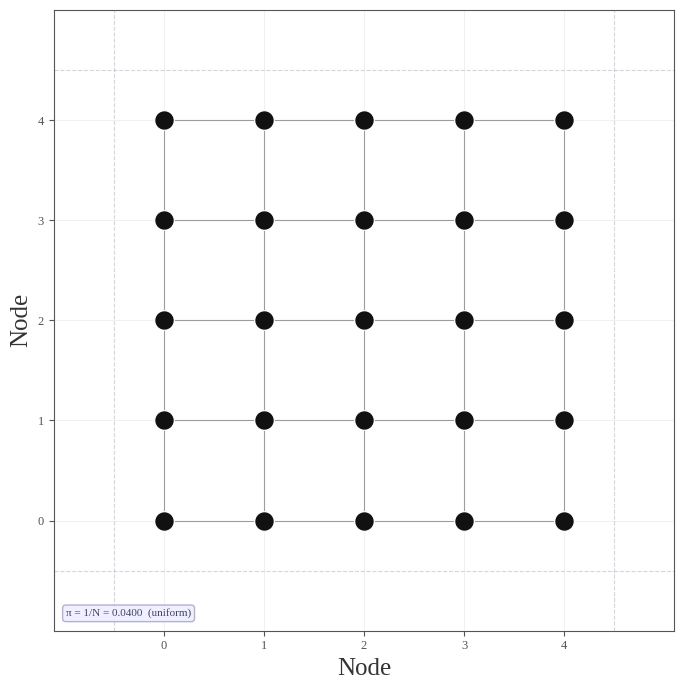

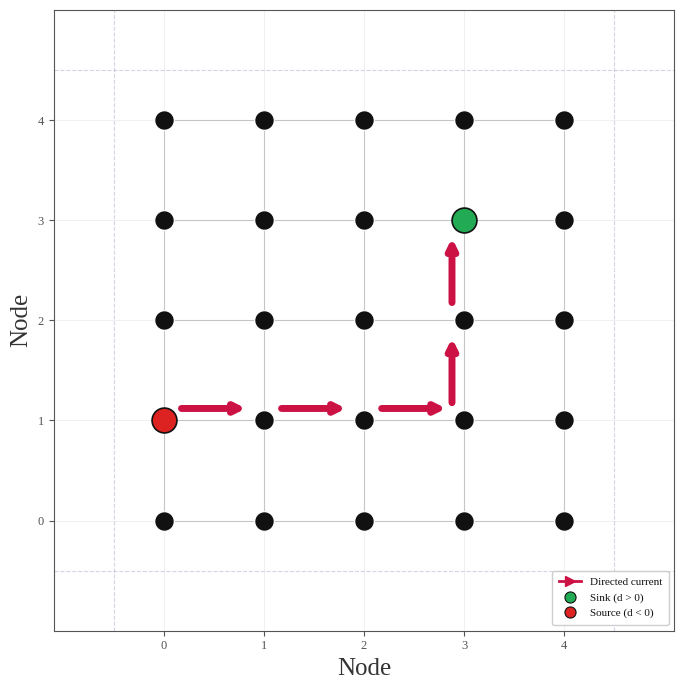

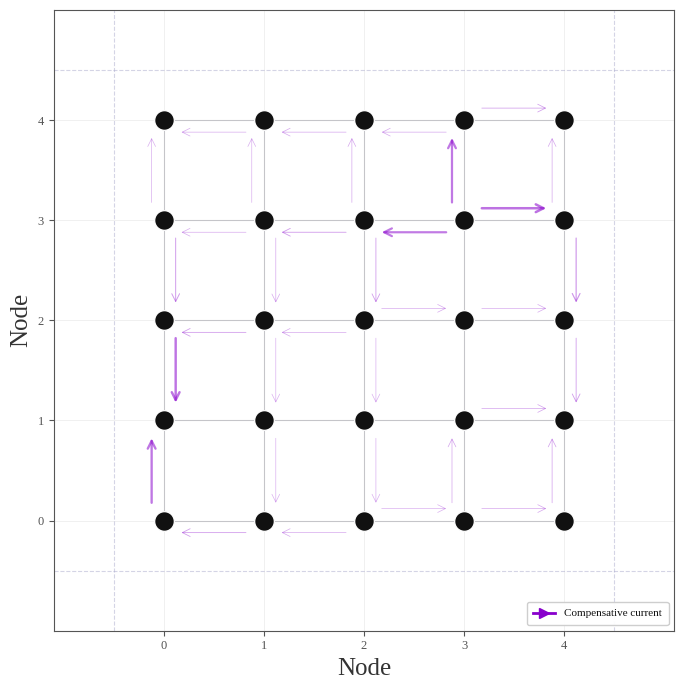

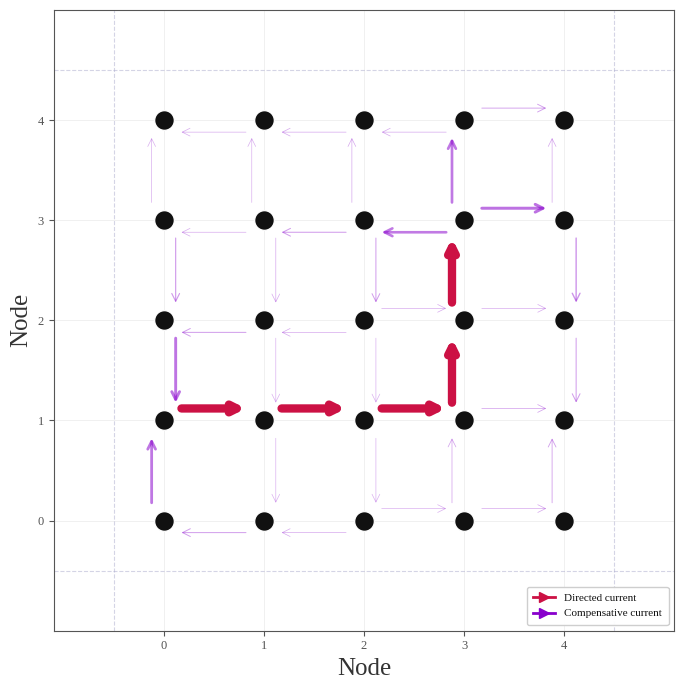


✓ Figure salvate: panel1_db_rates.png, panel2_directed.png, panel3_compensative.png, panel4_ness_complete.png


In [ ]:
import matplotlib.lines as mlines
import matplotlib.patches as mpatches

# ── palette ──────────────────────────────────────────────────────────────────
C_NODE    = '#111111'  # black nodes
C_DIR     = '#cc1144'
C_COMP    = '#8800cc'  # purple compensative currents
C_SINK    = '#22aa55'
C_SOURCE  = '#dd2222'
C_EDGE_BG = '#555566'  # era '#ccccdd'

# ── helpers ───────────────────────────────────────────────────────────────────

plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Liberation Serif"],
    "mathtext.fontset": "custom",
    "mathtext.rm": "Liberation Serif",
    "mathtext.it": "Liberation Serif:italic",
    "mathtext.bf": "Liberation Serif:bold",
})

def _raw_arrow(ax, x0, y0, x1, y1, value, max_val, color, lw_max, offset):
    """Disegna una freccia da (x0,y0) a (x1,y1) senza correzione periodica."""
    dx, dy = x1 - x0, y1 - y0
    norm = (dx**2 + dy**2)**0.5
    if norm < 1e-10:
        return
    px, py = -dy/norm * offset, dx/norm * offset
    sx = x0 + px + dx*0.15
    sy = y0 + py + dy*0.15
    lw    = max(0.5, lw_max * abs(value) / max_val)
    alpha = min(0.3 + 0.7 * abs(value) / max_val, 1.0)
    ax.annotate('', xy=(sx + dx*0.70, sy + dy*0.70), xytext=(sx, sy),
                arrowprops=dict(arrowstyle='->', color=color,
                                lw=lw, alpha=alpha, mutation_scale=14))

def draw_arrow(ax, p_i, p_j, value, max_val, color, lw_max=4, offset=0.12):
    if max_val < 1e-14 or abs(value) < 1e-12:
        return
    xi, yi = p_i
    xj, yj = p_j
    dx, dy = xj - xi, yj - yi
    wrap_x = abs(dx) > Lx / 2
    wrap_y = abs(dy) > Ly / 2

    if not wrap_x and not wrap_y:
        _raw_arrow(ax, xi, yi, xj, yj, value, max_val, color, lw_max, offset)
        return

    xj_v = xj - np.sign(dx)*Lx if wrap_x else xj
    yj_v = yj - np.sign(dy)*Ly if wrap_y else yj

    t_candidates = []
    if wrap_x:
        border_x = -0.5 if dx < 0 else Lx - 0.5
        if abs(xj_v - xi) > 1e-10:
            t_candidates.append((border_x - xi) / (xj_v - xi))
    if wrap_y:
        border_y = -0.5 if dy < 0 else Ly - 0.5
        if abs(yj_v - yi) > 1e-10:
            t_candidates.append((border_y - yi) / (yj_v - yi))
    if not t_candidates:
        return
    valid = [t for t in t_candidates if 0 < t < 1]
    if not valid:
        return
    t = min(valid)

    xm  = xi + t * (xj_v - xi)
    ym  = yi + t * (yj_v - yi)
    xm2 = xm - (np.sign(dx)*Lx if wrap_x else 0)
    ym2 = ym - (np.sign(dy)*Ly if wrap_y else 0)

    _raw_arrow(ax, xi,  yi,  xm,  ym,  value, max_val, color, lw_max, offset)
    _raw_arrow(ax, xm2, ym2, xj,  yj,  value, max_val, color, lw_max, offset)


def setup_ax(ax):
    ax.set_facecolor('#ffffff')
    ax.set_xlim(-1.1, Lx + 0.1)
    ax.set_ylim(-1.1, Ly + 0.1)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.25, lw=0.5, color='#aaaaaa')
    ax.set_xticks(range(Lx))
    ax.set_yticks(range(Ly))
    ax.set_xlabel('Node', color='#333333', fontsize=18, fontfamily='Liberation Serif')
    ax.set_ylabel('Node', color='#333333', fontsize=18, fontfamily='Liberation Serif')
    ax.tick_params(colors='#555555', labelsize=9)

    for spine in ax.spines.values():
        spine.set_edgecolor('#555555')

    for x in [-0.5, Lx - 0.5]:
        ax.axvline(x, color='#aaaacc', lw=0.8, ls='--', alpha=0.5)
    for y in [-0.5, Ly - 0.5]:
        ax.axhline(y, color='#aaaacc', lw=0.8, ls='--', alpha=0.5)


def scatter_nodes(ax, special=None):
    normal = [i for i in range(N) if special is None or i not in special]
    xs = [pos[i][0] for i in normal]
    ys = [pos[i][1] for i in normal]
    ax.scatter(xs, ys, c=C_NODE, s=200, zorder=5,
               edgecolors='#ffffff', linewidths=0.9)
    if special:
        for idx, col in special.items():
            ax.scatter(*pos[idx], c=col, s=320, zorder=6,
                       edgecolors='#111111', linewidths=1.2)


def draw_bg_edges(ax, alpha=0.4):
    for i, j in edges:
        xi, yi = pos[i]
        xj, yj = pos[j]
        dx, dy = xj - xi, yj - yi
        wrap_x = abs(dx) > Lx / 2
        wrap_y = abs(dy) > Ly / 2
        if not wrap_x and not wrap_y:
            ax.plot([xi, xj], [yi, yj], color=C_EDGE_BG, lw=0.8,
                    alpha=alpha, zorder=1)
        else:
            xj_v = xj - np.sign(dx)*Lx if wrap_x else xj
            yj_v = yj - np.sign(dy)*Ly if wrap_y else yj
            t_candidates = []
            if wrap_x and abs(xj_v - xi) > 1e-10:
                border_x = -0.5 if dx < 0 else Lx - 0.5
                t_candidates.append((border_x - xi) / (xj_v - xi))
            if wrap_y and abs(yj_v - yi) > 1e-10:
                border_y = -0.5 if dy < 0 else Ly - 0.5
                t_candidates.append((border_y - yi) / (yj_v - yi))
            if not t_candidates:
                continue
            valid = [t for t in t_candidates if 0 < t < 1]
            if not valid:
                continue
            t = min(valid)
            xm  = xi + t*(xj_v - xi);  ym  = yi + t*(yj_v - yi)
            xm2 = xm - (np.sign(dx)*Lx if wrap_x else 0)
            ym2 = ym - (np.sign(dy)*Ly if wrap_y else 0)
            kw = dict(color=C_EDGE_BG, lw=0.8, alpha=alpha, zorder=1)
            ax.plot([xi, xm],   [yi, ym],   **kw)
            ax.plot([xm2, xj],  [ym2, yj],  **kw)


def add_legend(ax, handles):
    leg = ax.legend(handles=handles, loc='lower right', fontsize=8,
                    facecolor='#ffffff', edgecolor='#cccccc', framealpha=0.95,
                    borderpad=0.6, handlelength=2.0)
    for text in leg.get_texts():
        text.set_color('#111111')


# ── scale factors ─────────────────────────────────────────────────────────────
max_J1 = max(abs(J_1[i,j]) for j,i in directed_transitions if abs(J_1[i,j])>1e-12)
max_Jf = np.max(np.abs(J_full))


# =============================================================================
# Panel 1 — Detailed Balance
# =============================================================================
fig1, ax = plt.subplots(figsize=(7, 7))
fig1.patch.set_facecolor('#ffffff')
setup_ax(ax)
draw_bg_edges(ax, alpha=0.6)
scatter_nodes(ax)
ax.text(0.02, 0.02, f'π = 1/N = {1/N:.4f}  (uniform)',
        transform=ax.transAxes, fontsize=8, color='#444466', va='bottom',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#eeeeff',
                  edgecolor='#aaaacc', alpha=0.9))
plt.tight_layout()
plt.savefig('panel1_db_rates.png', dpi=150, bbox_inches='tight', facecolor='#ffffff')
plt.show()

# =============================================================================
# Panel 2 — Directed edges + divergences
# =============================================================================
fig2, ax = plt.subplots(figsize=(7, 7))
fig2.patch.set_facecolor('#ffffff')
setup_ax(ax)
draw_bg_edges(ax, alpha=0.3)
special2 = {i: (C_SINK if div_1[i] > 0 else C_SOURCE)
            for i in range(N) if abs(div_1[i]) > 1e-10}
scatter_nodes(ax, special=special2)
for j, i in directed_transitions:
    draw_arrow(ax, pos[j], pos[i], abs(J_1[i,j]), max_J1, C_DIR, lw_max=5)
add_legend(ax, [
    mlines.Line2D([], [], color=C_DIR, lw=2, marker='>', markersize=7,
                  label='Directed current'),
    mlines.Line2D([], [], color=C_SINK, marker='o', ls='None', markersize=8,
                  markeredgecolor='#111', markeredgewidth=0.8, label='Sink (d > 0)'),
    mlines.Line2D([], [], color=C_SOURCE, marker='o', ls='None', markersize=8,
                  markeredgecolor='#111', markeredgewidth=0.8, label='Source (d < 0)'),
])
plt.tight_layout()
plt.savefig('panel2_directed.png', dpi=150, bbox_inches='tight', facecolor='#ffffff')
plt.show()

# =============================================================================
# Panel 3 — Compensative currents
# =============================================================================
fig3, ax = plt.subplots(figsize=(7, 7))
fig3.patch.set_facecolor('#ffffff')
setup_ax(ax)
draw_bg_edges(ax, alpha=0.3)
scatter_nodes(ax)
for i in range(N):
    for j in range(i+1, N):
        jv = J_comp[i, j]
        if abs(jv) > 1e-10:
            if jv > 0:
                draw_arrow(ax, pos[j], pos[i],  jv, max_Jf, C_COMP, lw_max=5)
            else:
                draw_arrow(ax, pos[i], pos[j], -jv, max_Jf, C_COMP, lw_max=5)
add_legend(ax, [
    mlines.Line2D([], [], color=C_COMP, lw=2, marker='>', markersize=7,
                  label='Compensative current'),
])

plt.tight_layout()
plt.savefig('panel3_compensative.png', dpi=150, bbox_inches='tight', facecolor='#ffffff')
plt.show()

# =============================================================================
# Panel 4 — Full NESS stationary currents
# =============================================================================
fig4, ax = plt.subplots(figsize=(7, 7))
fig4.patch.set_facecolor('#ffffff')
setup_ax(ax)
scatter_nodes(ax)
for i in range(N):
    for j in range(i+1, N):
        jv = J_full[i, j]
        if abs(jv) > 1e-10:
            is_dir = ((j,i) in D or (i,j) in D_block or
                      (i,j) in D or (j,i) in D_block)
            col = C_DIR if is_dir else C_COMP
            if jv > 0:
                draw_arrow(ax, pos[j], pos[i],  jv, max_Jf, col, lw_max=6)
            else:
                draw_arrow(ax, pos[i], pos[j], -jv, max_Jf, col, lw_max=6)
add_legend(ax, [
    mlines.Line2D([], [], color=C_DIR,  lw=2, marker='>', markersize=7,
                  label='Directed current'),
    mlines.Line2D([], [], color=C_COMP, lw=2, marker='>', markersize=7,
                  label='Compensative current'),
])
plt.tight_layout()
plt.savefig('panel4_ness_complete.png', dpi=150, bbox_inches='tight', facecolor='#ffffff')
plt.show()

print('\n✓ Figure salvate: panel1_db_rates.png, panel2_directed.png, '
      'panel3_compensative.png, panel4_ness_complete.png')

## Step 9: Statistiche di Riepilogo


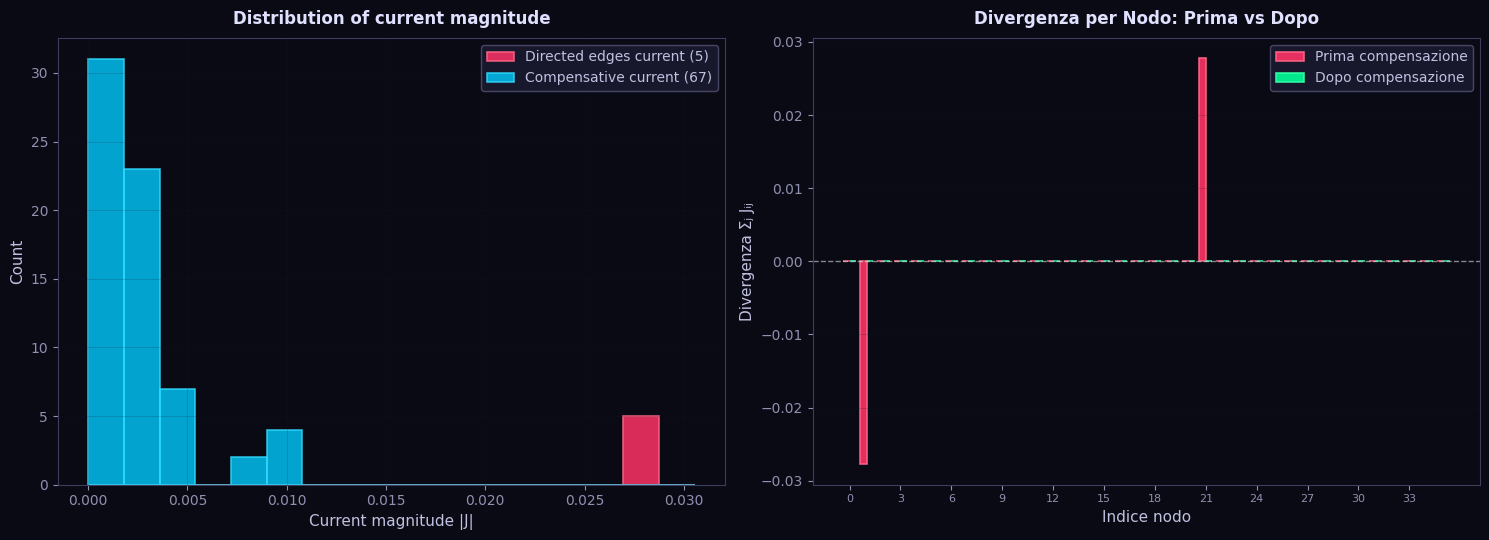


✓ Figura riepilogo salvata: ness_summary.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
fig.patch.set_facecolor('#0a0a15')

# Left: Istogramma magnitudini correnti
ax = axes[0]
ax.set_facecolor('#0a0a15')

J_dir_vals = [abs(J_full[i,j]) for j,i in directed_transitions if abs(J_full[i,j])>1e-12]
J_und_vals = []
for i, j in edges:
    is_dir = (j,i) in D or (i,j) in D_block or (i,j) in D or (j,i) in D_block
    if not is_dir and abs(J_full[i,j]) > 1e-12:
        J_und_vals.append(abs(J_full[i,j]))

all_vals = J_dir_vals + J_und_vals
if all_vals:
    bins = np.linspace(0, max(all_vals)*1.1, 18)
else:
    bins = [0, 1]

ax.hist(J_dir_vals, bins=bins, color='#ff3366', alpha=0.85, edgecolor='#ff6688',
        label=f'Directed edges current ({len(J_dir_vals)})', linewidth=1.2)
ax.hist(J_und_vals, bins=bins, color='#00ccff', alpha=0.80, edgecolor='#33ddff',
        label=f'Compensative current ({len(J_und_vals)})', linewidth=1.2)

ax.set_xlabel('Current magnitude |J|', fontsize=11, color='#c0c0e0')
ax.set_ylabel('Count', fontsize=11, color='#c0c0e0')
ax.set_title('Distribution of current magnitude', fontsize=12,
             color='#e0e0ff', fontweight='bold', pad=10)
ax.legend(fontsize=10, facecolor='#1a1a30', edgecolor='#4d4d6c', framealpha=0.9)
ax.grid(True, alpha=0.25, lw=0.5)

# Right: Divergenze prima vs dopo
ax = axes[1]
ax.set_facecolor('#0a0a15')

xs = np.arange(N)
width = 0.38

ax.bar(xs - width/2, div_1, width=width, color='#ff3366', alpha=0.9,
       label='Prima compensazione', edgecolor='#ff6688', linewidth=1.2)
ax.bar(xs + width/2, div_full, width=width, color='#00ff99', alpha=0.9,
       label='Dopo compensazione', edgecolor='#33ffaa', linewidth=1.2)

ax.axhline(0, color='#ffffff', lw=1.0, alpha=0.5, ls='--')
ax.set_xlabel('Indice nodo', fontsize=11, color='#c0c0e0')
ax.set_ylabel('Divergenza Σⱼ Jᵢⱼ', fontsize=11, color='#c0c0e0')
ax.set_title('Divergenza per Nodo: Prima vs Dopo',
             fontsize=12, color='#e0e0ff', fontweight='bold', pad=10)
ax.legend(fontsize=10, facecolor='#1a1a30', edgecolor='#4d4d6c', framealpha=0.9)
ax.grid(True, alpha=0.25, lw=0.5, axis='y')
ax.set_xticks(xs[::3])
ax.set_xticklabels([f'{i}' for i in xs[::3]], fontsize=8)

plt.tight_layout()
plt.savefig('ness_summary.png', dpi=150, bbox_inches='tight', facecolor='#0a0a15')
plt.show()
print('\n✓ Figura riepilogo salvata: ness_summary.png')


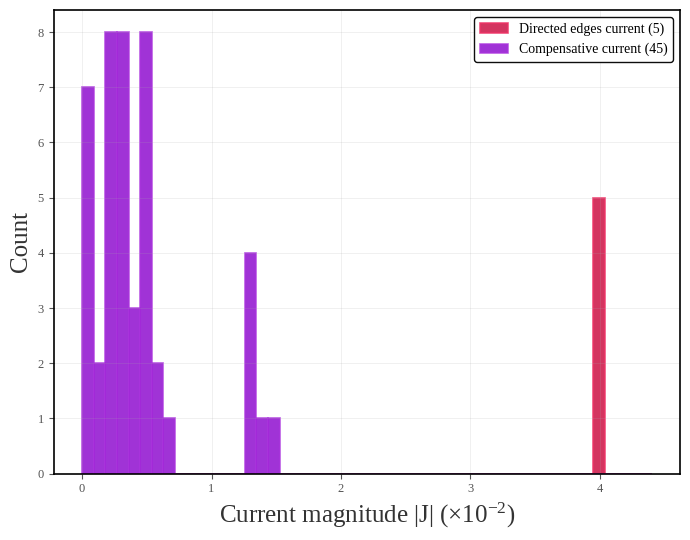

In [ ]:
# =============================================================================
# Figure A — Distribution of current magnitude
# =============================================================================
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Liberation Serif"],
    "mathtext.fontset": "custom",
    "mathtext.rm": "Liberation Serif",
    "mathtext.it": "Liberation Serif:italic",
    "mathtext.bf": "Liberation Serif:bold",
})

J_dir_vals = [abs(J_full[i,j]) for j,i in directed_transitions if abs(J_full[i,j])>1e-12]
J_und_vals = []
for i, j in edges:
    is_dir = (j,i) in D or (i,j) in D_block or (i,j) in D or (j,i) in D_block
    if not is_dir and abs(J_full[i,j]) > 1e-12:
        J_und_vals.append(abs(J_full[i,j]))

all_vals = J_dir_vals + J_und_vals
bins = np.linspace(0, max(all_vals)*1.1, 50) if all_vals else [0, 1]

figA, ax = plt.subplots(figsize=(7, 5.5))
figA.patch.set_facecolor('#ffffff')
ax.set_facecolor('#ffffff')

ax.hist(J_dir_vals, bins=bins, color='#cc1144', alpha=0.85, edgecolor='#ee3366',
        label=f'Directed edges current ({len(J_dir_vals)})', linewidth=1.2)
ax.hist(J_und_vals, bins=bins, color='#8800cc', alpha=0.80, edgecolor='#aa33dd',
        label=f'Compensative current ({len(J_und_vals)})', linewidth=1.2)

ax.set_xlabel('Current magnitude |J| $(\\times 10^{-2})$', fontsize=18, color='#333333', )
ax.set_ylabel('Count', fontsize=18, color='#333333')
ax.tick_params(colors='#555555', labelsize=9)

from matplotlib.ticker import FuncFormatter
exp = int(np.floor(np.log10(max(all_vals))))
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/10**exp:.1g}'))

leg = ax.legend(fontsize=10, facecolor='#ffffff', edgecolor='#000000', framealpha=0.95)
for text in leg.get_texts():
    text.set_color('#000000')

ax.grid(True, alpha=0.25, lw=0.5, color='#aaaaaa')
for spine in ax.spines.values():
    spine.set_edgecolor('#000000')
    spine.set_linewidth(1.2)

plt.tight_layout()
plt.savefig('hist_currents.png', dpi=150, bbox_inches='tight', facecolor='#ffffff')
plt.show()


l'immagine a destra ci mostra in rosso i nodi che prima della compensazione hanno divergenza diversa da zero, mentre in verde (non si vede perchè sono azzerati), i nodi che hanno divergenza non nulla dopo la compensazione

## Riepilogo Finale

### Risultati della Costruzione NESS

| Verifica | Atteso | Risultato |
|----------|--------|--------|
| DB violation (originale) | ~0 | Vedere Step 2 |
| Divergenza (dopo directing) | ≠0 | Vedere Step 4 |
| Divergenza (dopo compensazione) | ~0 | Vedere Step 5 |
| $\|\pi_{\text{actual}} - \pi_{\text{stat}}\|_\infty$ | ~0 | Vedere Step 6 |
| Entropy production rate | >0 | Vedere Step 6 |
| DB part: DB violation | ~0 | Vedere Step 7 |
| NESS part: divergenza | ~0 | Vedere Step 7 |

### Punti Chiave

1. **Distribuzione stazionaria preservata:** $\pi_i = v_i^2$ (dagli autovettori della matrice **simmetrica** originale) rimane stazionaria anche dopo l'introduzione di edges diretti.

2. **Tutte le correnti sono NESS:** La parte DB non contribuisce correnti ($J^{\text{DB}}_{ij} = 0$), tutte le correnti provengono dalla parte NESS.

3. **Meccanismo di compensazione:** Le correnti compensative sono calcolate risolvendo un problema di flow conservation via signed incidence matrix: $B \cdot f = -d^{(1)}$.

4. **Topologia del toro essenziale:** Le boundary conditions periodiche forniscono cicli non contraibili attraverso i quali le correnti compensative possono chiudersi.

5. **Entropy production:** EPR $> 0$ conferma che il sistema è in NESS (non-equilibrio), non in equilibrio termodinamico.
